In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoConfig
import numpy as np
from scipy.special import softmax
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("final_cleaned_trump_tweets.csv")

In [3]:
df["date"] = pd.to_datetime(df["date"], format="mixed")
df = df.rename(columns={"date": "datetime"})

In [5]:
MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)
config = AutoConfig.from_pretrained(MODEL)

# calculate polarity scores using RoBERTa model
def get_polarity(text):
    encoded_input = tokenizer(text, return_tensors='pt')
    output = model(**encoded_input)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    positive_score = scores[config.label2id['positive']]
    negative_score = scores[config.label2id['negative']]
    polarity_score = positive_score - negative_score
    return polarity_score



pytorch_model.bin:  71%|#######1  | 357M/501M [00:00<?, ?B/s]

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
# take sample of 500 for testing
sampled_df = df.sample(n=500, replace=True, random_state=340)
sampled_df.to_csv("test_set.csv")

# must manually label

In [6]:
# categorize polarity score as either positive or negative
def categorize_polarity(score):
    if score > 0:
        return 'positive'
    else:
        return 'negative'

## roBERTa Testing

In [7]:
test_set = pd.read_csv("new_test_set.csv")

In [8]:
# calculates Naive rule to have baseline accuracy

def calculate_naive_rule(df, column):
    category_counts = df[column].value_counts()
    most_frequent_category = category_counts.idxmax()
    naive_rule = np.round(category_counts.max() / category_counts.sum(), 2)
    return most_frequent_category, naive_rule

most_frequent_category, naive_rule = calculate_naive_rule(test_set, 'sentiment')

print(f"Most Frequent Category: {most_frequent_category}")
print(f"Naive Rule: {naive_rule}")


Most Frequent Category: positive
Naive Rule: 0.54


In [10]:
# calculates roBERTa accuracy
test_set['category'] = test_set['text'].astype(str).apply(get_polarity)

# categorizes polarity score
test_set['category'] = test_set['category'].apply(categorize_polarity)

# calculate accuracy
y_pred = test_set['category']
y_true = test_set['sentiment']

roberta_accuracy = np.round(accuracy_score(y_pred, y_true), 2)
print(f"RoBERTa Accuracy: {roberta_accuracy}")

RoBERTa Accuracy: 0.91


## Full RoBERTa Analysis

Assuming the model will be ~91% accurate for the entire dataset of 55k tweets, we ran the model on the entire dataset and used these findings for our analysis

In [ ]:
# run model on entire dataset and save so it won't have to be rerun
df['polarity'] = df['text'].astype(str).apply(get_polarity)
df['category'] = df['polarity'].apply(categorize_polarity)
df.to_csv("Full_BERT_sentiment.csv")

In [11]:
# Future Analysis: import full sentiment
df2 = pd.read_csv("Full_BERT_sentiment.csv")

In [12]:
# add sentiment to original dataset
df["sentiment"] = df2["sentiment"]

Descriptive Statistics about the full dataset

In [13]:
# overall sentiment
print(df['sentiment'].value_counts())

sentiment
positive    26221
negative    21450
Name: count, dtype: int64


In [14]:
overall = np.round(df["engagement"].mean(), 0)
print(f"Overall Engagement: {overall}")
df.groupby("sentiment")["engagement"].mean()


Overall Engagement: 22435.0


,engagement
sentiment,
negative,27049.114597
positive,18659.826704


In [15]:
overall = np.round(df["retweets"].mean(), 0)
print(f"Overall Retweets: {overall}")
df.groupby("sentiment")["retweets"].mean()

Overall Retweets: 4484.0


,retweets
sentiment,
negative,5677.587253
positive,3507.186454


In [16]:
overall = np.round(df["favorites"].mean(), 0)
print(f"Overall Favorites: {overall}")
df.groupby("sentiment")["favorites"].mean()

Overall Favorites: 17951.0


,favorites
sentiment,
negative,21371.527344
positive,15152.640250


Descriptive Statistics about the Date

In [17]:
min = df["datetime"].min()
max = df["datetime"].max()
print(f"Date Range: {min} to {max}")

Date Range: 2009-05-04 18:54:25 to 2024-11-04 15:20:27.839000


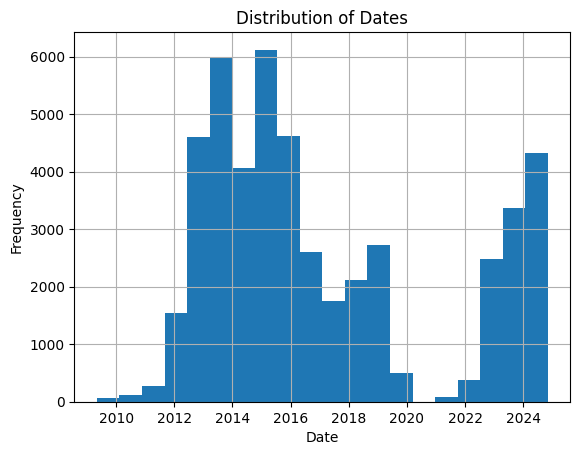

In [19]:
df["datetime"].hist(bins=20)  # Adjust bins for granularity
plt.title("Distribution of Dates")
plt.xlabel("Date")
plt.ylabel("Frequency")
plt.show()


In [31]:
df["year"] = df["datetime"].dt.year
df["month"] = df["datetime"].dt.month
df["date"] = df["datetime"].dt.date
df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.day_name()  # Day of the week
df["week"] = df["datetime"].dt.isocalendar().week

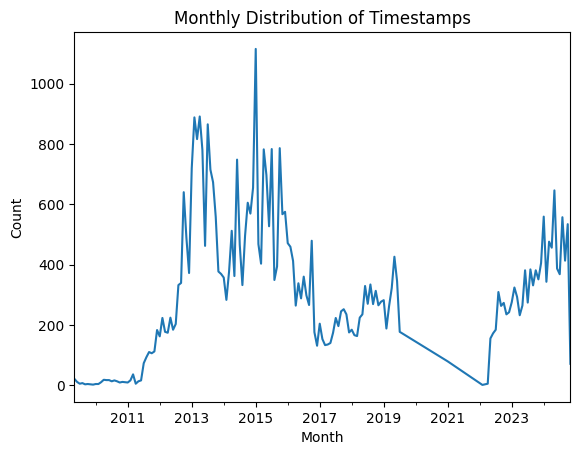

In [23]:
monthly_counts = df["datetime"].dt.to_period("M").value_counts().sort_index()
monthly_counts.plot(kind="line", title="Monthly Distribution of Timestamps")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()


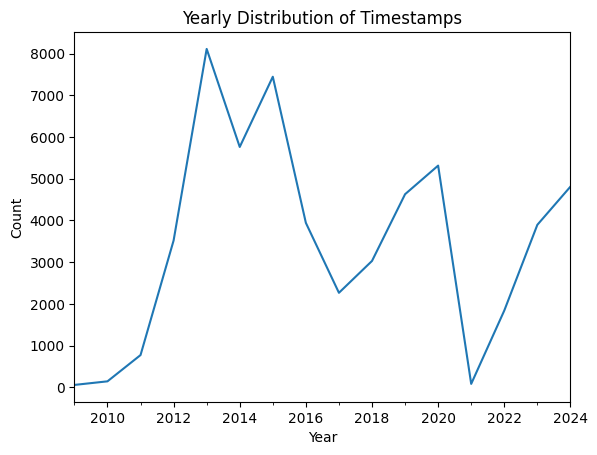

In [28]:
yearly_counts = df["datetime"].dt.to_period("Y").value_counts().sort_index()
yearly_counts.plot(kind="line", title="Yearly Distribution of Timestamps")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

In [24]:
# numerical encoding of negative to do sums
df['Is_Negative'] = (df['sentiment'] == "negative").astype(int)


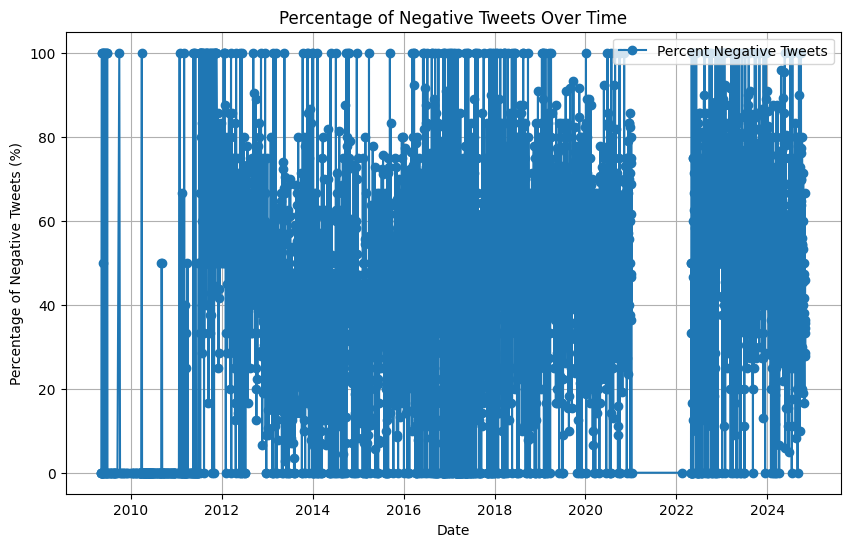

In [59]:
daily_stats = df.groupby('date').agg(
    Total_Tweets=('sentiment', 'count'),
    Negative_Tweets=('Is_Negative', 'sum')
)

daily_stats['Percent_Negative'] = (daily_stats['Negative_Tweets'] / daily_stats['Total_Tweets']) * 100

plt.figure(figsize=(10, 6))
plt.plot(daily_stats.index, daily_stats['Percent_Negative'], marker='o', label='Percent Negative Tweets')
plt.title('Percentage of Negative Tweets Over Time')
plt.xlabel('Date')
plt.ylabel('Percentage of Negative Tweets (%)')
plt.grid()
plt.legend()
plt.show()


In [26]:
aggregated_df = df.groupby('date').agg(
    Total_Tweets=('sentiment', 'count'),
    Negative_Tweets=('Is_Negative', 'sum')
).reset_index()

# Calculate the percentage of negative tweets
aggregated_df['Percent_Negative'] = (aggregated_df['Negative_Tweets'] / aggregated_df['Total_Tweets']) * 100

# Display the aggregated dataset
print(aggregated_df)

            date  Total_Tweets  Negative_Tweets  Percent_Negative
0     2009-05-04             1                0          0.000000
1     2009-05-05             1                0          0.000000
2     2009-05-08             2                0          0.000000
3     2009-05-12             2                2        100.000000
4     2009-05-13             1                0          0.000000
...          ...           ...              ...               ...
3861  2024-10-31            28               10         35.714286
3862  2024-11-01            24               11         45.833333
3863  2024-11-02            18                6         33.333333
3864  2024-11-03            22                8         36.363636
3865  2024-11-04             7                2         28.571429

[3866 rows x 4 columns]


In [27]:
date_agg = pd.DataFrame(aggregated_df)

In [29]:
date_agg["Percent_Negative"].mean()

43.93219383468904

In [86]:
date_agg.to_csv("date_agg.csv")

Statistics Using Individual Tweets

In [79]:
# Post-President Term

start_date = pd.to_datetime('2021-01-22')
end_date = pd.to_datetime(max)

df["date"] = pd.to_datetime(df["date"])

presidency = df[(df["date"] >= start_date) & (df["date"] <= end_date)]
average_sentiment = presidency["Is_Negative"].sum() / len(presidency["Is_Negative"])
average_engagement = presidency["engagement"].sum() / len(presidency["engagement"])
average_retweets = presidency["retweets"].sum() / len(presidency["retweets"])
average_favorites = presidency["favorites"].sum() / len(presidency["favorites"])

print(f"Average Sentiment Post-Presidency {average_sentiment}")
print(f"Average Engagement Post-Presidency {average_engagement}")
print(f"Average Retweets Post-Presidency {average_retweets}")
print(f"Average Favorites Post-Presidency {average_favorites}")

Average Sentiment Post-Presidency 0.5576631259484067
Average Engagement Post-Presidency 23840.25
Average Retweets Post-Presidency 5020.364946889226
Average Favorites Post-Presidency 18819.885053110775


In [80]:
# Pre-President Term

start_date = pd.to_datetime(min)
end_date = pd.to_datetime('2017-01-20')

df["date"] = pd.to_datetime(df["date"])

presidency = df[(df["date"] >= start_date) & (df["date"] <= end_date)]
average_sentiment = presidency["Is_Negative"].sum() / len(presidency["Is_Negative"])
average_engagement = presidency["engagement"].sum() / len(presidency["engagement"])
average_retweets = presidency["retweets"].sum() / len(presidency["retweets"])
average_favorites = presidency["favorites"].sum() / len(presidency["favorites"])

print(f"Average Sentiment Pre-Presidency {average_sentiment}")
print(f"Average Engagement Pre-Presidency {average_engagement}")
print(f"Average Retweets Pre-Presidency {average_retweets}")
print(f"Average Favorites Pre-Presidency {average_favorites}")

Average Sentiment Pre-Presidency 0.4042681295156543
Average Engagement Pre-Presidency 4497.571782178218
Average Retweets Pre-Presidency 1269.9501605565963
Average Favorites Pre-Presidency 3227.6216216216217


In [47]:
# President Term

start_date = pd.to_datetime('2017-01-21')
end_date = pd.to_datetime('2021-01-08')

df["date"] = pd.to_datetime(df["date"])

presidency = df[(df["date"] >= start_date) & (df["date"] <= end_date)]
average_sentiment = presidency["Is_Negative"].sum() / len(presidency["Is_Negative"])
average_engagement = presidency["engagement"].sum() / len(presidency["engagement"])
average_retweets = presidency["retweets"].sum() / len(presidency["retweets"])
average_favorites = presidency["favorites"].sum() / len(presidency["favorites"])

print(f"Average Sentiment Presidency {average_sentiment}")
print(f"Average Engagement Presidency {average_engagement}")
print(f"Average Retweets Presidency {average_retweets}")
print(f"Average Favorites Presidency {average_favorites}")


Average Sentiment Presidency 0.481881051175657
Average Engagement Presidency 94553.70885200553
Average Retweets Presidency 16990.15601659751
Average Favorites Presidency 77563.55283540802


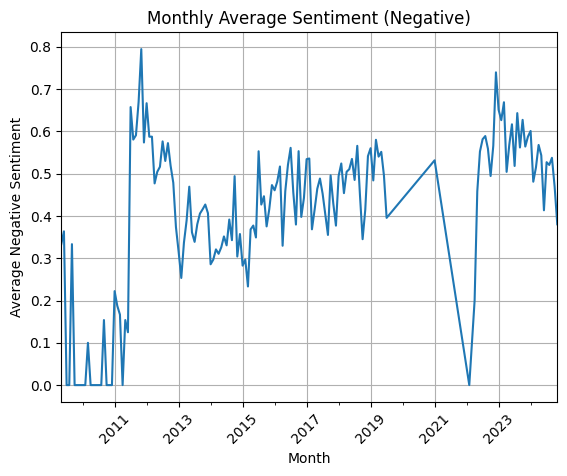

In [81]:
df["datetime"] = pd.to_datetime(df["datetime"])
df["month"] = df["datetime"].dt.to_period("M")
monthly_avg_sentiment = (
    df.groupby("month")["Is_Negative"].mean().sort_index()
)

monthly_avg_sentiment.plot(kind="line", title="Monthly Average Sentiment (Negative)")
plt.xlabel("Month")
plt.ylabel("Average Negative Sentiment")
plt.xticks(rotation=45)
plt.grid()
plt.show()


Key Events

In [51]:
# January 6

start_date = pd.to_datetime('2021-01-05')
end_date = pd.to_datetime('2021-01-08')

df["date"] = pd.to_datetime(df["date"])

presidency = df[(df["date"] >= start_date) & (df["date"] <= end_date)]
average_sentiment = presidency["Is_Negative"].sum() / len(presidency["Is_Negative"])
average_engagement = presidency["engagement"].sum() / len(presidency["engagement"])

print(f"Average Sentiment During January 6 {average_sentiment}")
print(f"Average Engagement January 6 {average_engagement}")

Average Sentiment During January 6 0.5172413793103449
Average Engagement January 6 278168.3793103448


In [61]:
# COVID 2020

start_date = pd.to_datetime('2020-03-01')
end_date = pd.to_datetime('2020-12-20')

df["date"] = pd.to_datetime(df["date"])

presidency = df[(df["date"] >= start_date) & (df["date"] <= end_date)]
presidency = presidency.dropna(subset=["Is_Negative", "engagement"])
average_sentiment = presidency["Is_Negative"].sum() / len(presidency["Is_Negative"])
average_engagement = presidency["engagement"].sum() / len(presidency["engagement"])

print(f"Average Sentiment During COVID 2020 {average_sentiment}")
print(f"Average Engagement 2020 COVID {average_engagement}")

Average Sentiment During COVID 2020 nan
Average Engagement 2020 COVID nan


<ipython-input-61-83db32e8f2d8>:10: RuntimeWarning: invalid value encountered in scalar divide
  average_sentiment = presidency["Is_Negative"].sum() / len(presidency["Is_Negative"])
<ipython-input-61-83db32e8f2d8>:11: RuntimeWarning: invalid value encountered in scalar divide
  average_engagement = presidency["engagement"].sum() / len(presidency["engagement"])


In [59]:
# Government Shutdown

start_date = pd.to_datetime('2018-12-21')
end_date = pd.to_datetime('2019-01-25')

df["date"] = pd.to_datetime(df["date"])

presidency = df[(df["date"] >= start_date) & (df["date"] <= end_date)]
average_sentiment = presidency["Is_Negative"].sum() / len(presidency["Is_Negative"])
average_engagement = presidency["engagement"].sum() / len(presidency["engagement"])

print(f"Average Sentiment During Shutdown {average_sentiment}")
print(f"Average Engagement Shutdown {average_engagement}")

Average Sentiment During COVID 2020 0.5552147239263804
Average Engagement 2020 COVID 127010.35582822085


In [63]:
# 2017

start_date = pd.to_datetime('2017-01-21')
end_date = pd.to_datetime('2017-12-31')

df["date"] = pd.to_datetime(df["date"])

presidency = df[(df["date"] >= start_date) & (df["date"] <= end_date)]
average_sentiment = presidency["Is_Negative"].sum() / len(presidency["Is_Negative"])
average_engagement = presidency["engagement"].sum() / len(presidency["engagement"])

print(f"Average Sentiment During 2017 {average_sentiment}")
print(f"Average Engagement 2017 {average_engagement}")

Average Sentiment During 2017 0.43443396226415093
Average Engagement 2017 86021.66367924528


In [69]:
# COVID 2020

start_date = pd.to_datetime('2020-03-01')
end_date = pd.to_datetime('2021-01-01')

df["date"] = pd.to_datetime(df["date"])

presidency = df[(df["date"] >= start_date) & (df["date"] <= end_date)]
average_sentiment = presidency["Is_Negative"].sum() / len(presidency["Is_Negative"])
average_engagement = presidency["engagement"].sum() / len(presidency["engagement"])

print(f"Average Sentiment During 2017 {average_sentiment}")
print(f"Average Engagement 2017 {average_engagement}")

Average Sentiment During 2017 0.47058823529411764
Average Engagement 2017 224105.5294117647


In [73]:
# Midterm Elections

start_date = pd.to_datetime('2018-11-01')
end_date = pd.to_datetime('2018-11-09')

df["date"] = pd.to_datetime(df["date"])

presidency = df[(df["date"] >= start_date) & (df["date"] <= end_date)]
average_sentiment = presidency["Is_Negative"].sum() / len(presidency["Is_Negative"])
average_engagement = presidency["engagement"].sum() / len(presidency["engagement"])

print(f"Average Sentiment Midterms {average_sentiment}")
print(f"Average Engagement Midterms {average_engagement}")

Average Sentiment Midterms 0.2897196261682243
Average Engagement Midterms 81003.7663551402


In [74]:
# Tax Cuts

start_date = pd.to_datetime('2017-12-22')
end_date = pd.to_datetime('2017-12-25')

df["date"] = pd.to_datetime(df["date"])

presidency = df[(df["date"] >= start_date) & (df["date"] <= end_date)]
average_sentiment = presidency["Is_Negative"].sum() / len(presidency["Is_Negative"])
average_engagement = presidency["engagement"].sum() / len(presidency["engagement"])

print(f"Average Sentiment Tax Cuts {average_sentiment}")
print(f"Average Engagement Tax Cuts {average_engagement}")

Average Sentiment Tax Cuts 0.34782608695652173
Average Engagement Tax Cuts 115690.34782608696
